# F1 Strategy — Prédiction de Pit Stop

**Objectif :** Prédire si un pilote va s'arrêter aux stands au prochain tour (`PitNextLap`).

| Étape | Contenu |
|---|---|
| 1 | Chargement & exploration des données |
| 2 | Nettoyage & preprocessing |
| 3 | Visualisations |
| 4 | Préparation des features |
| 5 | Entraînement du modèle |
| 6 | Évaluation |
| 7 | Feature importance |

---
## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay
)

# Affichage propre
pd.set_option('display.max_columns', 20)
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='darkgrid')

print('Imports OK')

Imports OK


---
## 1. Chargement & Exploration

In [2]:
df = pd.read_csv('f1_strategy_dataset_v4.csv')
print(f'Dimensions : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
df.head()

Dimensions : 101,371 lignes × 16 colonnes


,Driver,LapNumber,Compound,Stint,TyreLife,Position,LapTime (s),Race,Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change
0,ALB,1,MEDIUM,1,2.0,17,100.625,Abu Dhabi Grand Prix,2023,0.000,0.000,0,0,0.017241,0.117647,0.0
1,ALB,2,MEDIUM,1,3.0,18,93.560,Abu Dhabi Grand Prix,2023,-7.065,-7.065,0,0,0.034483,0.176471,-1.0
2,ALB,3,MEDIUM,1,4.0,18,91.768,Abu Dhabi Grand Prix,2023,-1.792,-8.857,0,0,0.051724,0.235294,0.0
3,ALB,4,MEDIUM,1,5.0,18,91.591,Abu Dhabi Grand Prix,2023,-0.177,-9.034,0,0,0.068966,0.294118,0.0
4,ALB,5,MEDIUM,1,6.0,18,91.422,Abu Dhabi Grand Prix,2023,-0.169,-9.203,0,0,0.086207,0.352941,0.0


In [3]:
# Types et valeurs manquantes
info = pd.DataFrame({
    'dtype': df.dtypes,
    'non_null': df.notnull().sum(),
    'null': df.isnull().sum(),
    'unique': df.nunique()
})
info

,dtype,non_null,null,unique
Driver,str,101371,0,31
LapNumber,int64,101371,0,78
Compound,str,101305,66,5
Stint,int64,101371,0,8
TyreLife,float64,101371,0,78
Position,int64,101371,0,20
LapTime (s),float64,101371,0,40779
Race,str,101371,0,28
Year,int64,101371,0,4
LapTime_Delta,float64,101371,0,54084


In [4]:
# Statistiques descriptives des colonnes numériques
df.describe().round(2)

,LapNumber,Stint,TyreLife,Position,LapTime (s),Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change
count,101371.00,101371.00,101371.00,101371.00,101371.00,101371.00,101371.00,101371.00,101371.00,101371.00,101371.00,101371.00,101371.00
mean,30.44,2.05,14.55,9.76,92.59,2023.59,-0.20,-29.55,0.25,0.25,0.43,0.39,-0.00
std,18.15,0.95,10.31,5.41,33.23,1.10,45.34,70.24,0.43,0.44,0.26,0.26,3.91
min,1.00,1.00,1.00,1.00,67.01,2022.00,-2403.90,-274.56,0.00,0.00,0.01,0.01,-18.00
25%,15.00,1.00,7.00,5.00,82.02,2023.00,-7.25,-51.05,0.00,0.00,0.21,0.17,-2.00
50%,30.00,2.00,13.00,10.00,91.17,2024.00,-0.03,-21.68,0.00,0.00,0.42,0.33,0.00
75%,45.00,3.00,20.00,14.00,99.36,2025.00,5.70,-3.73,1.00,1.00,0.63,0.56,2.00
max,78.00,8.00,78.00,20.00,2526.25,2025.00,2433.47,2412.43,1.00,1.00,1.00,1.00,18.00


In [5]:
print('Courses :', df['Race'].nunique())
print('Pilotes :', df['Driver'].nunique())
print('Années  :', sorted(df['Year'].unique()))
print('Composés:', df['Compound'].unique())

Courses : 28
Pilotes : 31
Années  : [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Composés: <StringArray>
['MEDIUM', 'HARD', 'SOFT', 'INTERMEDIATE', 'WET', nan]
Length: 6, dtype: str


---
## 2. Nettoyage & Preprocessing

In [6]:
# Supprimer les lignes avec Compound manquant (très peu)
df = df.dropna(subset=['Compound'])

# Supprimer les tours aberrants (SC, VSC, problèmes mécaniques)
# Un tour normal en F1 dure entre 60s et 200s
df = df[(df['LapTime (s)'] >= 60) & (df['LapTime (s)'] <= 200)]

# Garder uniquement les composés secs (on exclut wet/intermédiaire pour simplifier)
df = df[df['Compound'].isin(['SOFT', 'MEDIUM', 'HARD'])]

print(f'Lignes après nettoyage : {len(df):,}')
print(f'Distribution de la cible PitNextLap :')
print(df['PitNextLap'].value_counts())
print(f'\nRatio de pit stops : {df["PitNextLap"].mean():.2%}')

Lignes après nettoyage : 95,330
Distribution de la cible PitNextLap :
PitNextLap
0    70632
1    24698
Name: count, dtype: int64

Ratio de pit stops : 25.91%


---
## 3. Visualisations

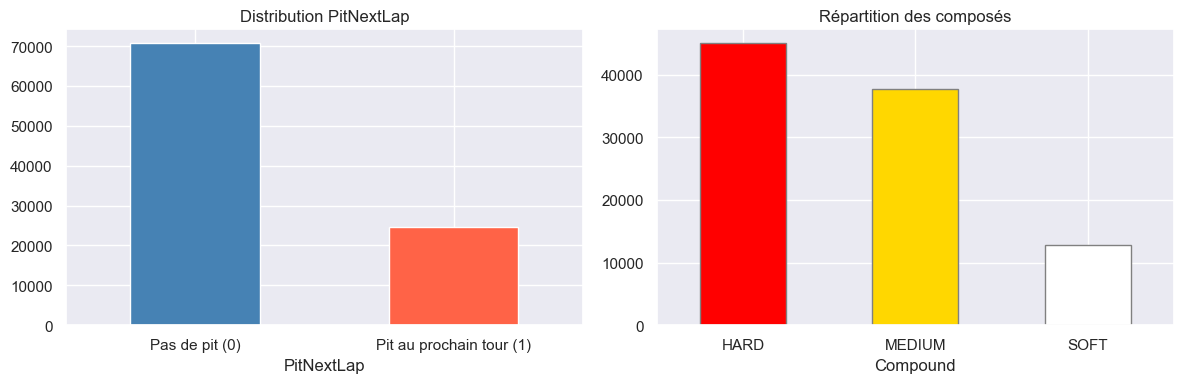

In [7]:
# Distribution des pit stops
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['PitNextLap'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'])
axes[0].set_title('Distribution PitNextLap')
axes[0].set_xticklabels(['Pas de pit (0)', 'Pit au prochain tour (1)'], rotation=0)

df['Compound'].value_counts().plot(kind='bar', ax=axes[1], color=['red', 'gold', 'white'], edgecolor='gray')
axes[1].set_title('Répartition des composés')
axes[1].set_xticklabels(df['Compound'].value_counts().index, rotation=0)

plt.tight_layout()
plt.show()

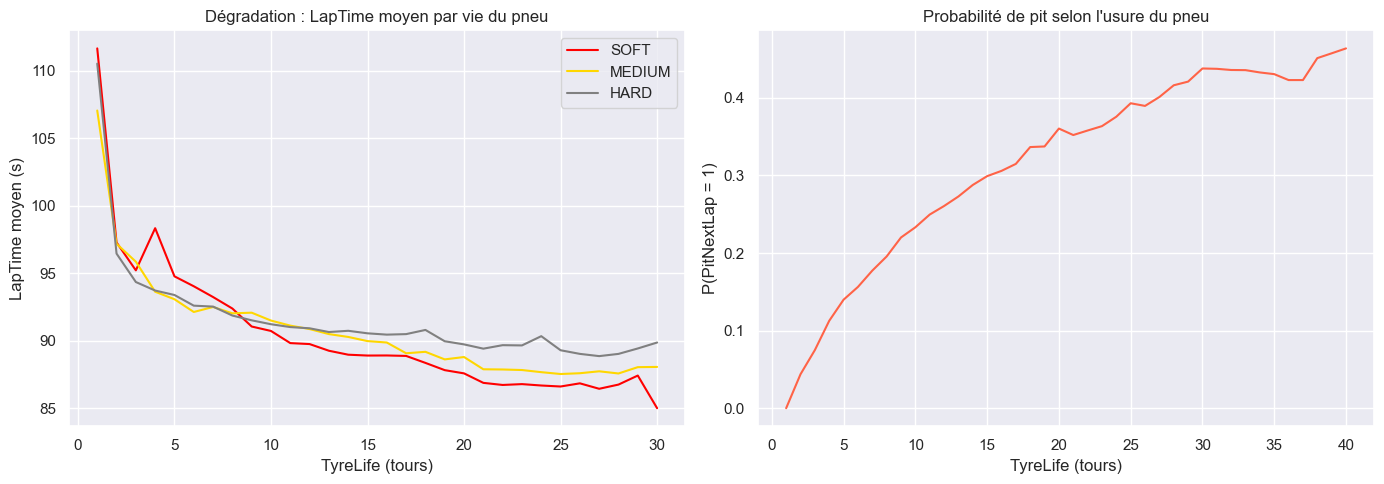

In [8]:
# Dégradation des pneus par composé
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for compound, color in zip(['SOFT', 'MEDIUM', 'HARD'], ['red', 'gold', 'gray']):
    subset = df[df['Compound'] == compound]
    avg = subset.groupby('TyreLife')['LapTime (s)'].mean()
    axes[0].plot(avg.index[:30], avg.values[:30], label=compound, color=color)

axes[0].set_title('Dégradation : LapTime moyen par vie du pneu')
axes[0].set_xlabel('TyreLife (tours)')
axes[0].set_ylabel('LapTime moyen (s)')
axes[0].legend()

# Probabilité de pit selon TyreLife
pit_by_life = df.groupby('TyreLife')['PitNextLap'].mean()
axes[1].plot(pit_by_life.index[:40], pit_by_life.values[:40], color='tomato')
axes[1].set_title('Probabilité de pit selon l\'usure du pneu')
axes[1].set_xlabel('TyreLife (tours)')
axes[1].set_ylabel('P(PitNextLap = 1)')

plt.tight_layout()
plt.show()

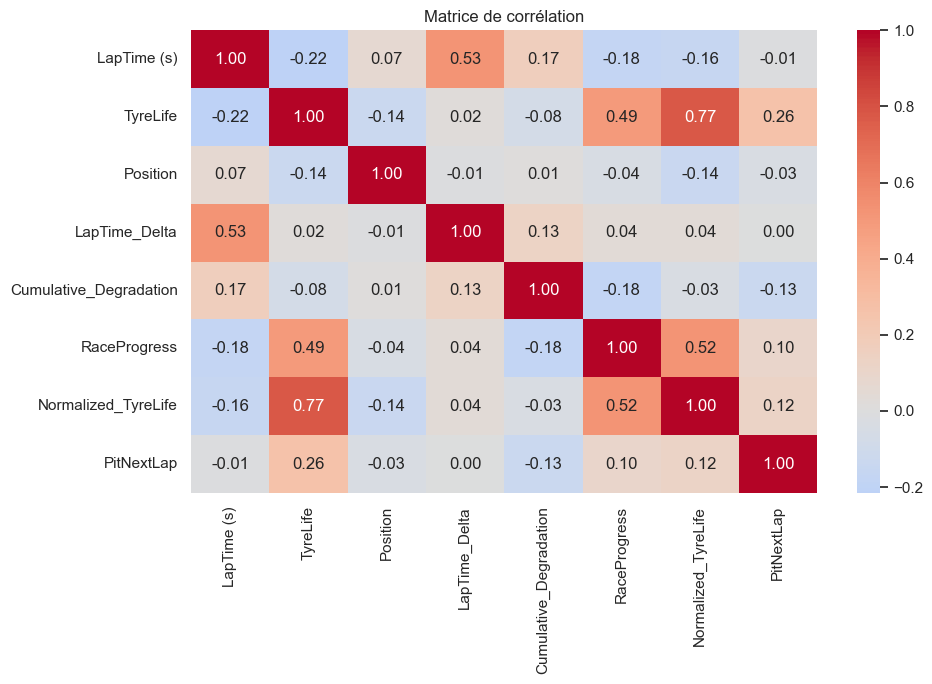

In [9]:
# Corrélation entre les features numériques
num_cols = ['LapTime (s)', 'TyreLife', 'Position', 'LapTime_Delta',
            'Cumulative_Degradation', 'RaceProgress', 'Normalized_TyreLife', 'PitNextLap']

plt.figure(figsize=(10, 7))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matrice de corrélation')
plt.tight_layout()
plt.show()

---
## 4. Préparation des Features

In [10]:
# Encoder le composé (catégoriel → numérique)
le = LabelEncoder()
df['Compound_enc'] = le.fit_transform(df['Compound'])
print('Mapping composés :', dict(zip(le.classes_, le.transform(le.classes_))))

# Features retenues
FEATURES = [
    'TyreLife',
    'Compound_enc',
    'Cumulative_Degradation',
    'LapTime_Delta',
    'Position',
    'RaceProgress',
    'Normalized_TyreLife',
    'Stint',
]

TARGET = 'PitNextLap'

X = df[FEATURES]
y = df[TARGET]

print(f'\nX shape : {X.shape}')
print(f'y shape : {y.shape}')

Mapping composés : {'HARD': np.int64(0), 'MEDIUM': np.int64(1), 'SOFT': np.int64(2)}

X shape : (95330, 8)
y shape : (95330,)


In [11]:
# Split train / test (80% / 20%)
# stratify=y pour conserver la même proportion de pit stops dans les deux sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train : {len(X_train):,} lignes | Test : {len(X_test):,} lignes')
print(f'Ratio pit dans train : {y_train.mean():.2%}')
print(f'Ratio pit dans test  : {y_test.mean():.2%}')

Train : 76,264 lignes | Test : 19,066 lignes
Ratio pit dans train : 25.91%
Ratio pit dans test  : 25.91%


---
## 5. Entraînement des Modèles

In [12]:
# --- Modèle 1 : Régression Logistique (baseline simple) ---
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
print('=== Régression Logistique ===')
print(classification_report(y_test, y_pred_lr, target_names=['Pas de pit', 'Pit']))

=== Régression Logistique ===
              precision    recall  f1-score   support

  Pas de pit       0.78      0.94      0.85     14126
         Pit       0.58      0.23      0.33      4940

    accuracy                           0.76     19066
   macro avg       0.68      0.59      0.59     19066
weighted avg       0.73      0.76      0.72     19066



In [13]:
# --- Modèle 2 : Random Forest ---
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print('=== Random Forest ===')
print(classification_report(y_test, y_pred_rf, target_names=['Pas de pit', 'Pit']))

=== Random Forest ===
              precision    recall  f1-score   support

  Pas de pit       0.93      0.97      0.95     14126
         Pit       0.89      0.78      0.83      4940

    accuracy                           0.92     19066
   macro avg       0.91      0.87      0.89     19066
weighted avg       0.92      0.92      0.92     19066



---
## 6. Évaluation

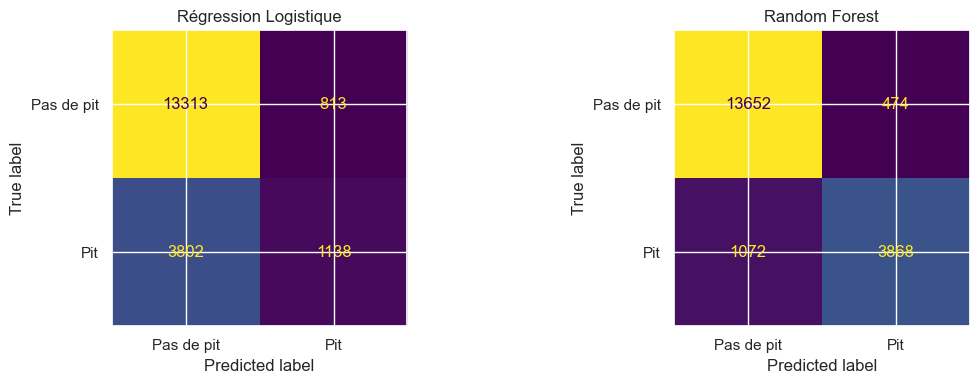

In [14]:
# Matrices de confusion côte à côte
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, model, name, y_pred in zip(
    axes,
    [lr, rf],
    ['Régression Logistique', 'Random Forest'],
    [y_pred_lr, y_pred_rf]
):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Pas de pit', 'Pit'])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

C:\Users\steve\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\steve\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


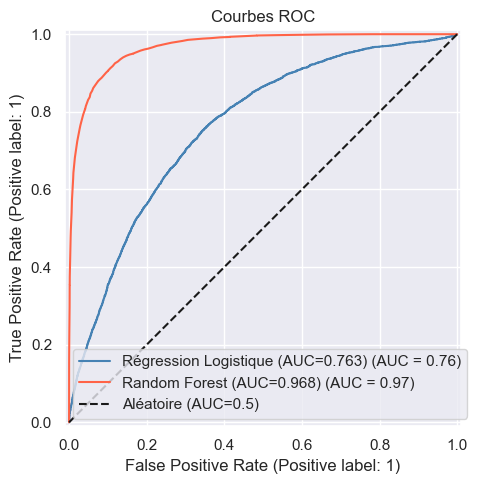

In [15]:
# Courbes ROC
fig, ax = plt.subplots(figsize=(7, 5))

for model, name, color in zip(
    [lr, rf],
    ['Régression Logistique', 'Random Forest'],
    ['steelblue', 'tomato']
):
    y_proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
    RocCurveDisplay.from_predictions(y_test, y_proba, name=f'{name} (AUC={auc:.3f})', ax=ax, color=color)

ax.plot([0, 1], [0, 1], 'k--', label='Aléatoire (AUC=0.5)')
ax.set_title('Courbes ROC')
ax.legend()
plt.tight_layout()
plt.show()

---
## 7. Feature Importance

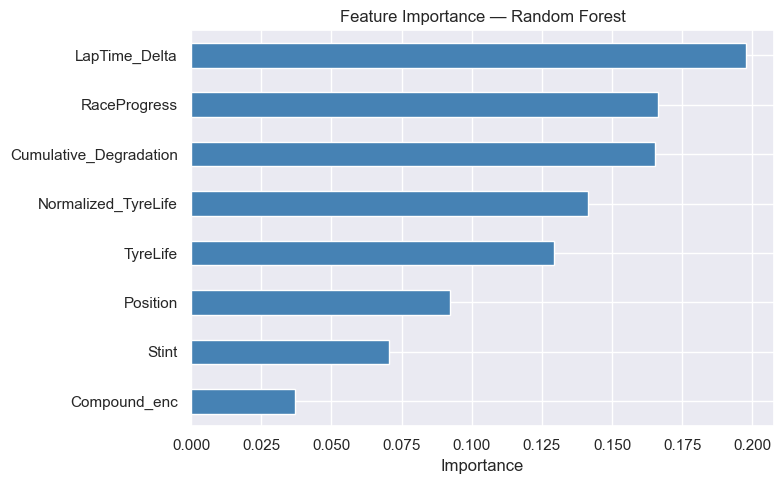

LapTime_Delta             0.197808
RaceProgress              0.166246
Cumulative_Degradation    0.165235
Normalized_TyreLife       0.141355
TyreLife                  0.129446
Position                  0.092407
Stint                     0.070360
Compound_enc              0.037143
dtype: float64


In [16]:
# Quelles features comptent le plus pour le Random Forest ?
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='steelblue')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print(importances.sort_values(ascending=False))

---
## 8. Pour aller plus loin (optionnel)

Quelques pistes pour améliorer le modèle :

```python
# Option A : Gérer le déséquilibre des classes
rf_balanced = RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42)

# Option B : Essayer XGBoost
# pip install xgboost
from xgboost import XGBClassifier
xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')

# Option C : Optimiser les hyperparamètres
from sklearn.model_selection import GridSearchCV
param_grid = {'n_estimators': [50, 100, 200], 'max_depth': [5, 10, None]}
grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3, scoring='f1')
```